In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
import pandas as pd


In [2]:
from src.preference_factors.build_datasets import build_EBC_dataset 

In [3]:
# df_EBC_monthly_returns, df_EBC_monthly_weights, df_EBC_monthly_beta_contributions = build_EBC_dataset(
#     returns_file="sp500_returns_monthly_with_tickers.csv",
#     ff_factors_file="ff_factors_monthly.csv",
#     frequency="monthly")

In [4]:
from src.preference_factors.build_datasets import build_all_dataset, build_returns_dataset
from src.FamaMacBeth.betas import compute_rolling_betas
from src.FamaMacBeth.pipeline import run_full_factor_pipeline

merged_df, full_merged_df = build_all_dataset(
    returns_file="sp500_returns_monthly_with_tickers.csv",
    market_caps_file="sp500_market_caps_monthly.csv",
    ff_factors_file="ff_factors_monthly.csv",
    frequency="monthly"
)

ebc = merged_df["EBC"]
cw_ebc = merged_df["CW-EBC"]


/Users/santi/PycharmProjects/Invesco_Research_Project/src/preference_factors/build_EBC.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_weights = full_weights.fillna(0.0)


In [5]:
ebc = ebc.to_frame(name="EBC")
cw_ebc = cw_ebc.to_frame(name="CW-EBC")

In [6]:
asset_returns = build_returns_dataset("sp500_returns_monthly_with_tickers.csv", frequency="monthly")
factor_returns = pd.concat([ebc, cw_ebc], axis=1).dropna()
factor_returns.columns = ["EBC", "CW-EBC"]

asset_returns, factor_returns = asset_returns.align(factor_returns, join="inner", axis=0)

betas_ebc = compute_rolling_betas(asset_returns, ebc, rolling_window=36, min_obs=10)
betas_cw_ebc = compute_rolling_betas(asset_returns, cw_ebc, rolling_window=36, min_obs=10)



Estimating rolling betas: 100%|██████████| 666/666 [00:02<00:00, 329.55it/s]


In [16]:
results = run_full_factor_pipeline(
    beta1_df=betas_ebc,
    beta2_df=betas_cw_ebc,
    sp500=asset_returns,
    EBC=factor_returns["EBC"],
    Cap_EBC=factor_returns["CW-EBC"],
    n_q1=3,
    n_q2=3,
    min_assets_per_cell=3,
    f1_name="EBC",
    f2_name="CW-EBC",
)

results["mean_grid"]

forming portfolios: 100%|██████████| 666/666 [00:04<00:00, 149.98it/s]


,1,2,3
1,0.011339,0.011925,0.013645
2,0.010253,0.011274,0.012357
3,0.008865,0.010140,0.010981


In [17]:
results["portrets_wide"][6:]

,Q1_Q1,Q1_Q2,Q1_Q3,Q2_Q1,Q2_Q2,Q2_Q3,Q3_Q1,Q3_Q2,Q3_Q3
date,,,,,,,,,
1970-01,-0.095687,-0.042302,-0.056279,-0.091769,-0.079405,-0.019759,-0.070625,-0.046074,-0.005774
1970-02,0.085391,0.098991,0.106917,0.063145,0.063136,0.072445,0.048485,0.076519,0.047817
1970-03,-0.004320,0.001947,-0.009299,-0.000282,0.015115,0.019490,-0.008021,0.012760,0.049140
1970-04,-0.123656,-0.152165,-0.133842,-0.110734,-0.083396,-0.097425,-0.093413,-0.078547,-0.080654
1970-05,-0.079801,-0.094388,-0.100798,-0.091162,-0.067152,-0.089478,-0.067557,-0.049543,-0.050107
...,...,...,...,...,...,...,...,...,...
2024-08,-0.006582,0.001970,0.012638,0.023997,0.031330,0.010367,0.054058,0.047262,0.041332
2024-09,0.013395,0.045578,0.037663,0.023088,0.032785,0.003032,0.001790,0.015211,0.008962
2024-10,-0.051356,-0.007531,-0.018272,-0.007765,-0.007765,-0.009009,-0.015079,-0.013850,-0.021029


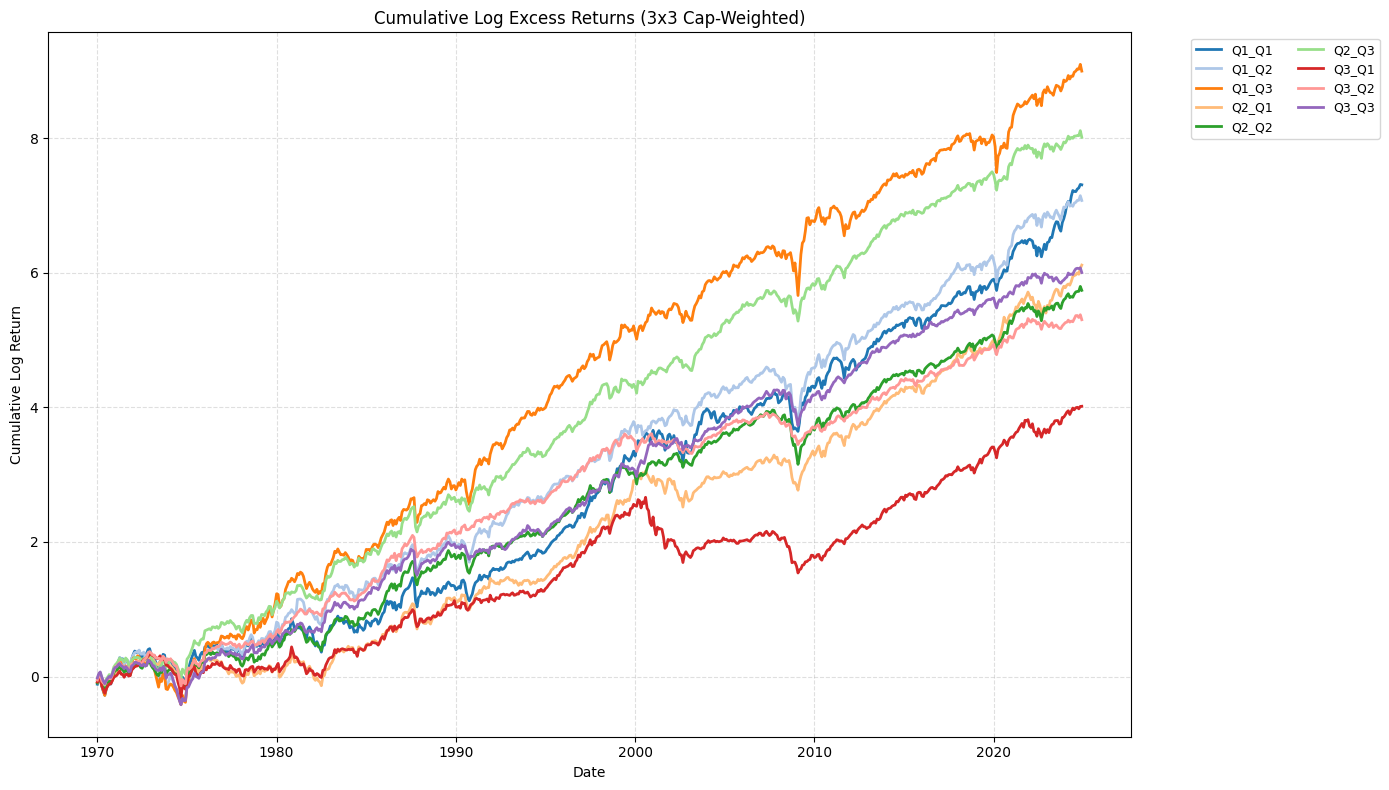

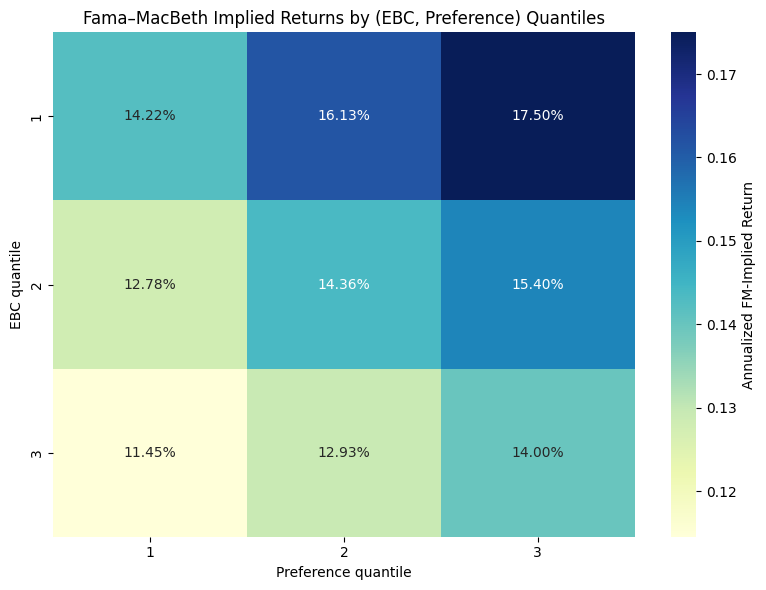

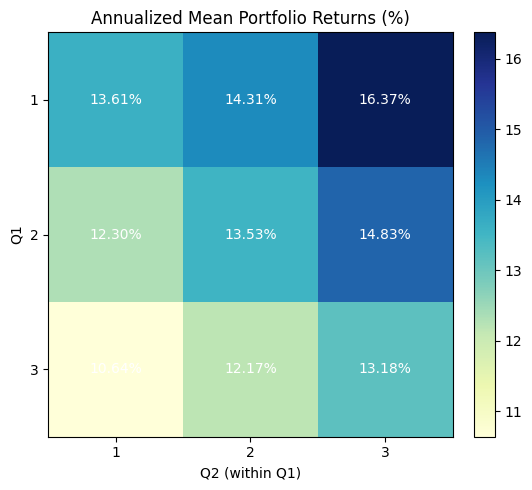

In [18]:
from pathlib import Path
from src.FamaMacBeth.backtest import (
    load_monthly_inputs,
    backtest_quantile_portfolios,
    compute_excess_returns,
)
from src.FamaMacBeth.plots import (
    plot_cum_log_returns,
    plot_expected_return_grid,
)
from src.FamaMacBeth.plots import plot_mean_grid

# ============================
# USER PARAMETERS
# ============================
start_date = "1970-01-01"
use_excess_returns = True

# ============================
# REQUIRED INPUTS FROM PIPELINE
# ============================
members_df = results["members"]
n_q1, n_q2 = results["mean_grid"].shape

# ============================
# LOAD RETURNS / CAPS / RF
# ============================
DATA_RAW_DIR = Path.cwd().parent / "data" / "raw"
sp_500, sp_caps, rf = load_monthly_inputs(DATA_RAW_DIR)

# ============================
# RUN BACKTEST
# ============================
all_portfolio_returns = backtest_quantile_portfolios(
    members_df=members_df,
    returns_df=sp_500,
    caps_df=sp_caps,
    n_q1=n_q1,
    n_q2=n_q2,
    weight="cap",
)

if use_excess_returns:
    all_portfolio_returns = compute_excess_returns(
        all_portfolio_returns, rf, start_date=start_date
    )
else:
    all_portfolio_returns = all_portfolio_returns.loc[start_date:]

# ============================
# PLOTS
# ============================
plot_cum_log_returns(
    all_portfolio_returns,
    title=f"Cumulative Log Excess Returns ({n_q1}x{n_q2} Cap-Weighted)",
)

# FM expected-return grid (annualized %)
plot_expected_return_grid(results["pricing"], results["fm_table"], n_q1, n_q2)


plot_mean_grid(results["mean_grid"], annualize=True)




In [19]:
all_portfolio_returns.to_csv("quantile3x3_monthly_returns.csv")